# 🧠 CNN (Convolutional Neural Networks) ТОЛЫҚ НҰСҚАУЛЫҚ

Бұл құжат CNN-нің қалай жұмыс істейтінін түсіндіретін толық шпаргалка. Бұны Google Colab-тың **Text** ұяшығына қойыңыз.

---

## 1. CNN НЕГІЗГІ ТЕРМИНДЕРІ

| Ұғым | Сипаттамасы | Мақсаты |
| :--- | :--- | :--- |
| **Ядро (Kernel)** | 3x3 немесе 5x5 матрица | Суреттен белгілерді (сызық, бұрыш) іздеу |
| **Stride (Қадам)** | Фильтрдің сырғу қадамы | Есептеу жылдамдығын реттеу |
| **Padding** | Шетіне нөлдер қосу | Сурет өлшемін сақтап қалу |
| **ReLU** | Activation function | Теріс сандарды 0-ге айналдыру |
| **Pooling** | Max Pooling | Маңызды ақпаратты сығымдау |



---

## 2. МОДЕЛЬДІҢ ОҚУ ЦИКЛІ

1. **Forward Pass:** Сурет желіден өтіп, болжам жасалады.
2. **Loss Function:** Болжам мен шындықтың айырмашылығы (қате) есептеледі.
3. **Backpropagation:** Қателік сигнал ретінде артқа тарап, **Градиенттер** табылады.
4. **Optimizer (Adam):** Градиентке қарап, фильтр салмақтарын (сандарын) жаңартады.



---

## 3. 28x28 СУРЕТТІҢ ӨҢДЕЛУІ (PIPELINE)

* **Input (28, 28, 1):** Бастапқы сурет.
* **Conv2D (32 filters):** 32 түрлі белгі картасы жасалады (26, 26, 32).
* **MaxPooling (2, 2):** Өлшем екі есе кішірейеді (13, 13, 32).
* **Flatten:** Барлық сандар бір қатарға тізіледі (5408 нейрон).
* **Dense (10):** Соңғы 10 класс (сан) бойынша ықтималдық шығады.



---

## 4. ПРАКТИКАЛЫҚ КОД

Бұл кодты Colab-тың **Code** ұяшығына бөлек көшіріп қойыңыз:

```python
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Деректерді жүктеу
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 2. Модель құрылымы
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3. Жинақтау және Оқыту
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)

# 🛠 MNIST CNN ҚҰРАСТЫРУ БОЙЫНША ТАПСЫРМА

Бұл қадамдарды орындау арқылы сен өз бетіңше цифрларды танитын нейрондық желі жасайсың.

---

## 1-ҚАДАМ: Деректерді жүктеу және форматтау
`tf.keras.datasets.mnist.load_data()` функциясымен деректі алғаннан кейін:

* **Масштабтау (Normalizing):** Пиксель мәндерін [0, 255] аралығынан [0, 1] аралығына келтіру үшін не істеу керек?
* **Пішінді өзгерту (Reshape):** CNN суретті 4 өлшемді (сурет саны, биіктік, ені, канал) пішінде қабылдайды. MNIST сұр түсті болғандықтан, канал саны - **1**.
  * *Сұрақ:* `x_train` пішінін қалай `(60000, 28, 28, 1)` қыласың?



---

In [ ]:
# import library
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# load dataset
mnist = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
(x_train, y_train), (x_test, y_test) = mnist

In [ ]:
x_train.shape, x_test.shape  # shape of datas

((60000, 28, 28), (10000, 28, 28))

In [ ]:
y_train.shape, y_test.shape # shape of datas

((60000,), (10000,))

In [ ]:
x_train, x_test = x_train / 255.0, x_test / 255.0  # normalizing

In [ ]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)  # reshape

## 2-ҚАДАМ: Модель архитектурасын құру
`models.Sequential` қолданып, келесі қабаттарды ретімен тіз:

1.  **Conv2D қабаты:** * `filters`: Қанша белгі іздейсің? (Мысалы: 16, 32 немесе 64).
    * `kernel_size`: "Терезе" өлшемі қандай болады? (Стандарт: `(3,3)`).
    * `activation`: Сызықтық емес функция (ReLU).
    * `input_shape`: Бірінші қабатқа сурет өлшемін көрсетуді ұмытпа.
2.  **MaxPooling2D қабаты:** * `pool_size`: Суретті қанша есе сығымдайсың? (Стандарт: `(2,2)`).
3.  **Екінші Conv2D қабаты:**
    * Модель тереңірек болу үшін тағы бір конволюция қос. Мұнда фильтр санын көбейткен дұрыс.
4.  **Flatten қабаты:** * Суретті классификаторға беру үшін векторға айналдыру.
5.  **Dense (Жасырын қабат):**
    * Қанша нейрон қосасың? Бұл модельдің "логикалық" бөлігі.
6.  **Dense (Шығыс қабаты):**
    * *Ойлан:* MNIST-те 0-ден 9-ға дейін неше сан бар? Шығыс нейроны сол санға тең болуы керек.
    * `activation`: Көп класты классификация үшін қандай функция керек? ('softmax' немесе 'sigmoid'?)



---

In [ ]:
model_mnist = tf.keras.models.Sequential([
    # Layer 1 - Conv2D
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),

    # Layer 2 - MaxPooling2D
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Layer 3 - Conv2D
    tf.keras.layers.Conv2D(
        filters = 64,
        kernel_size=(3, 3),
        activation='relu'
    ),

    # Layer 4 - Flatten
    tf.keras.layers.Flatten(),

    # Layer 5 - Hidden Dense
    tf.keras.layers.Dense(
        units=128,
        activation='relu'
    ),

    # Layer 6 - Output Dense
    tf.keras.layers.Dense(
        units=10,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 3-ҚАДАМ: Модельді жинақтау (Compile)
`model.compile()` ішінде мыналарды анықта:

* **Optimizer:** Градиенттерді түзету үшін қай алгоритм жақсы?
* **Loss:** Егер нышандар (labels) бүтін сандар (0, 1, 2...) болса, қай "Loss" түрін таңдайсың?
  * *Көмек:* `sparse_categorical_crossentropy` немесе `categorical_crossentropy`?
* **Metrics:** Сапаны немен өлшейміз? (Стандарт: `['accuracy']`).

---

In [ ]:
model_mnist.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model_mnist.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       991,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,011,466 (3.86 MB)

 Trainable params: 1,011,466 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

## 4-ҚАДАМ: Оқыту (Fit)
`model.fit()` функциясына `x_train` мен `y_train` бер.

* **Epochs:** Деректерді неше рет толық айналдырып шығасың? (Бастапқыда 5 немесе 10 жеткілікті).
* **Batch_size:** Бір қадамда неше суретті қатар өңдейсің? (Мысалы: 32 немесе 64).

---

In [ ]:
model_mnist.fit(x_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9257 - loss: 0.2447
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9884 - loss: 0.0359
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9940 - loss: 0.0196
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9963 - loss: 0.0124
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9967 - loss: 0.0105
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9971 - loss: 0.0086
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9979 - loss: 0.0058
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9983 - loss: 0.0052
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9980 - loss: 0.0064
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9990 - loss: 0.0032


## 5-ҚАДАМ: Тексеру және Болжау
* `model.evaluate(x_test, y_test)` арқылы тест деректеріндегі дәлдікті тексер.
* `model.predict(x_test)` арқылы бір суретті беріп, оның қай сан екенін модель қалай табатынын көр.
  * *Сұрақ:* Шыққан 10 санның (ықтималдықтың) ішінен ең үлкенін қалай табасың? (Көмек: `np.argmax`).

In [ ]:
model_mnist.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9874 - loss: 0.0540


[0.04249757528305054, 0.9900000095367432]

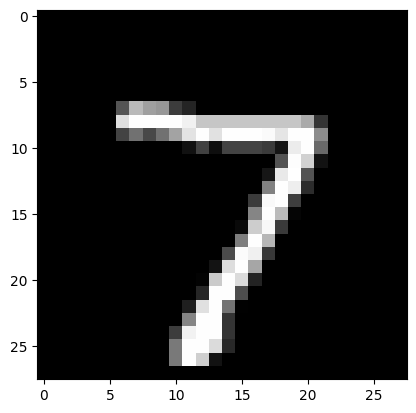

In [ ]:
img = x_test[0]

plt.imshow(img.reshape(28, 28), cmap='gray')
plt.show()

In [ ]:
# Суретті (1, 28, 28, 1) пішініне айналдыру
img_tensor = np.expand_dims(img, axis=0)

In [ ]:
prediction = model_mnist.predict(img_tensor)

# Нәтижені көру
print(f"Болжам нәтижесі (ықтималдықтар): \n{prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
Болжам нәтижесі (ықтималдықтар): 
[[6.8165209e-16 1.3776819e-11 4.9246824e-14 1.9203460e-12 8.5663155e-13
  6.9659556e-14 1.8412433e-19 1.0000000e+00 1.3268888e-15 6.5019019e-12]]


In [ ]:
predicted_label = np.argmax(prediction)
true_label = y_test[0]

print(f"Модельдің болжамы: {predicted_label}")
print(f"Шын мәні: {true_label}")

Модельдің болжамы: 7
Шын мәні: 7


In [ ]:
# Ескі нұсқаның орнына:
model_mnist.save('mnist_model.keras')